<a href="https://colab.research.google.com/github/Stonetenth2005/Machine-Learning/blob/main/21-Percentile-Outlier-Removal/Percentile_Outlier_Removal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
import pandas as pd
df = pd.read_csv('/content/weight-height.csv')

In [51]:
df.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [52]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


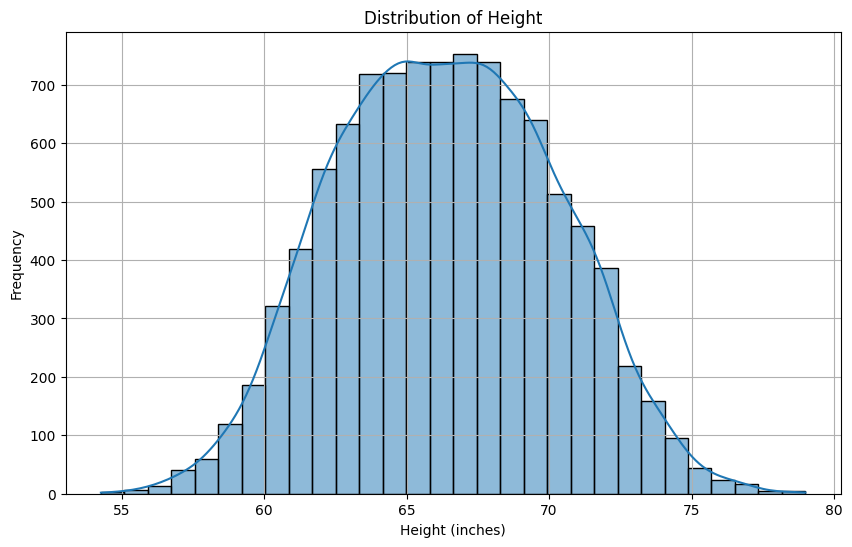

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.histplot(df['Height'], kde=True, bins=30)
plt.title('Distribution of Height')
plt.xlabel('Height (inches)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

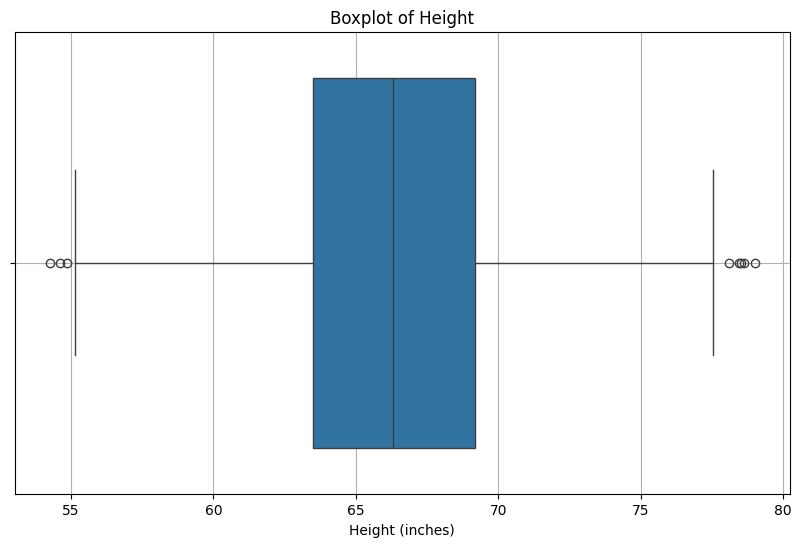

In [54]:
plt.figure(figsize=(10, 6))
sns.boxplot(x=df['Height'])
plt.title('Boxplot of Height')
plt.xlabel('Height (inches)')
plt.grid(True)
plt.show()

In [55]:
upper_limit = df['Height'].quantile(0.99)
lower_limit = df['Height'].quantile(0.01)

upper_limit

np.float64(74.7857900583366)

# Finding Outliers

Trimming

In [56]:
new_df = df[(df['Height']>=lower_limit) & (df['Height']<=upper_limit)]
new_df

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,69.034243,163.852461


In [57]:
df.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


In [58]:
new_df.describe()

,Height,Weight
count,9800.000000,9800.000000
mean,66.364366,161.399489
std,3.645075,30.933549
min,58.134496,77.523774
25%,63.577162,136.322717
50%,66.318070,161.212928
75%,69.119896,186.753317
max,74.785714,249.946283


Capping ---> Windsorization

In [59]:
import numpy as np
df['Height_capped'] = np.where(
    df['Height']>upper_limit,
    upper_limit,
    np.where(
        df['Height']<lower_limit,
        lower_limit,
        df['Height']
    )
)

In [60]:
df['Height'].describe()

,Height
count,10000.000000
mean,66.367560
std,3.847528
min,54.263133
25%,63.505620
50%,66.318070
75%,69.174262
max,78.998742


In [61]:
df['Height_capped'].describe()

,Height_capped
count,10000.000000
mean,66.366281
std,3.795717
min,58.134412
25%,63.505620
50%,66.318070
75%,69.174262
max,74.785790


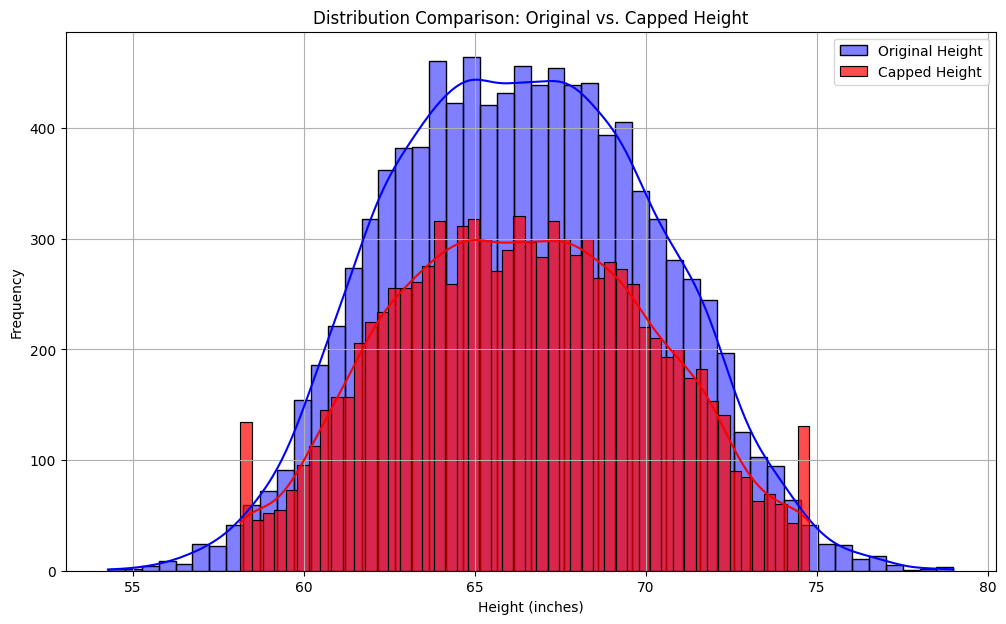

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sns.histplot(df['Height'], kde=True, bins=50, color='blue', label='Original Height')
sns.histplot(df['Height_capped'], kde=True, bins=50, color='red', label='Capped Height', alpha=0.7)
plt.title('Distribution Comparison: Original vs. Capped Height')
plt.xlabel('Height (inches)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()